# 06 — Event analysis: Bonfire Night & England World Cup 2026 matches

Hourly-resolution event studies on the cleaned, humidity-corrected network. All results use the **network median across sensors** (robust to any single misbehaving sensor); sensor-hours need >= `MIN_READ_PER_HOUR` readings, network-hours need >= `MIN_SENSORS_PER_HOUR` sensors.

**v2 changes** (after the first real run):
* per-sensor hourly table `hm` is cached too, enabling the sensor-count strips and the per-sensor enhancement map
* bonfire time series widened to 25 Oct – 12 Nov, weekday in titles, Fri/Sat evenings shaded grey (organised-display weekends), with a sensor-count strip under each panel explaining the line gaps
* diurnal composite re-centred **noon 5 Nov -> noon 6 Nov** so the full rise–peak–decay arc sits unbroken in one frame
* new **map of per-sensor bonfire enhancement** (city-wide check + where activity is most intense)

Timestamps are UTC in the raw data; events are defined in Europe/London and converted.

In [ ]:
import re
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.config import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.cleaning import apply_humidity_correction

MIN_READ_PER_HOUR    = 15
MIN_SENSORS_PER_HOUR = 5
LOCAL_TZ             = "Europe/London"

BONFIRE_YEARS = [2022, 2023, 2024, 2025]
EVENT_EXCLUDE = ["11-03", "11-04", "11-05", "11-06", "11-07"]

ENGLAND_MATCHES = [
    ("Croatia (group)",  "2026-06-17 21:00"),
    ("Ghana (group)",    "2026-06-23 21:00"),
    ("Panama (group)",   "2026-06-27 22:00"),
    ("DR Congo (R32)",   "2026-07-01 17:00"),
    # ("Mexico (R16)",   "2026-07-06 01:00"),   
]
MATCH_HOURS = 2

def short_code(name: str) -> str:
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

### Build (and cache) the per-sensor hourly table and the network median

In [ ]:
CACHE_HM  = PROCESSED / "network_hourly_sensors.parquet"

if CACHE_HM.exists():
    hm = pd.read_parquet(CACHE_HM)
    hm.index = pd.to_datetime(hm.index, utc=True)
    print(f"loaded cached per-sensor hourly table: {hm.shape}")
else:
    hourly = {}
    for path in sorted(CLEANED.glob("*.parquet")):
        df = pd.read_parquet(path)
        clean = df[df["is_clean"]].copy()
        if clean.empty:
            continue
        clean[DATE_COL]    = pd.to_datetime(clean[DATE_COL], utc=True)
        clean["pm25_corr"] = apply_humidity_correction(clean)
        clean = clean.dropna(subset=["pm25_corr"])
        agg = (clean.set_index(DATE_COL)["pm25_corr"]
                    .resample("h").agg(["mean", "count"]))
        hourly[path.stem] = agg.loc[agg["count"] >= MIN_READ_PER_HOUR, "mean"]
        print(f"  {path.stem}: {hourly[path.stem].notna().sum():,} valid hours")
    hm = pd.DataFrame(hourly).sort_index()
    hm.to_parquet(CACHE_HM)

n_sensors = hm.notna().sum(axis=1)
net       = hm.median(axis=1).where(n_sensors >= MIN_SENSORS_PER_HOUR)

net_local = net.copy();       net_local.index = net_local.index.tz_convert(LOCAL_TZ)
n_local   = n_sensors.copy(); n_local.index   = n_local.index.tz_convert(LOCAL_TZ)
print(f"network hourly median: {net.notna().sum():,} of {len(net):,} hours valid")

loaded cached per-sensor hourly table: (37697, 47)
network hourly median: 33,477 of 37,697 hours valid


## 1. Bonfire Night — wide time series with sensor-count strips

Per year: 25 Oct – 12 Nov network median (top), sensors reporting per hour (bottom). Gaps in the line are hours failing the `MIN_SENSORS_PER_HOUR` rule — the strip shows exactly why. Grey bands mark Fri/Sat evenings (organised displays); orange marks the bonfire evening itself.

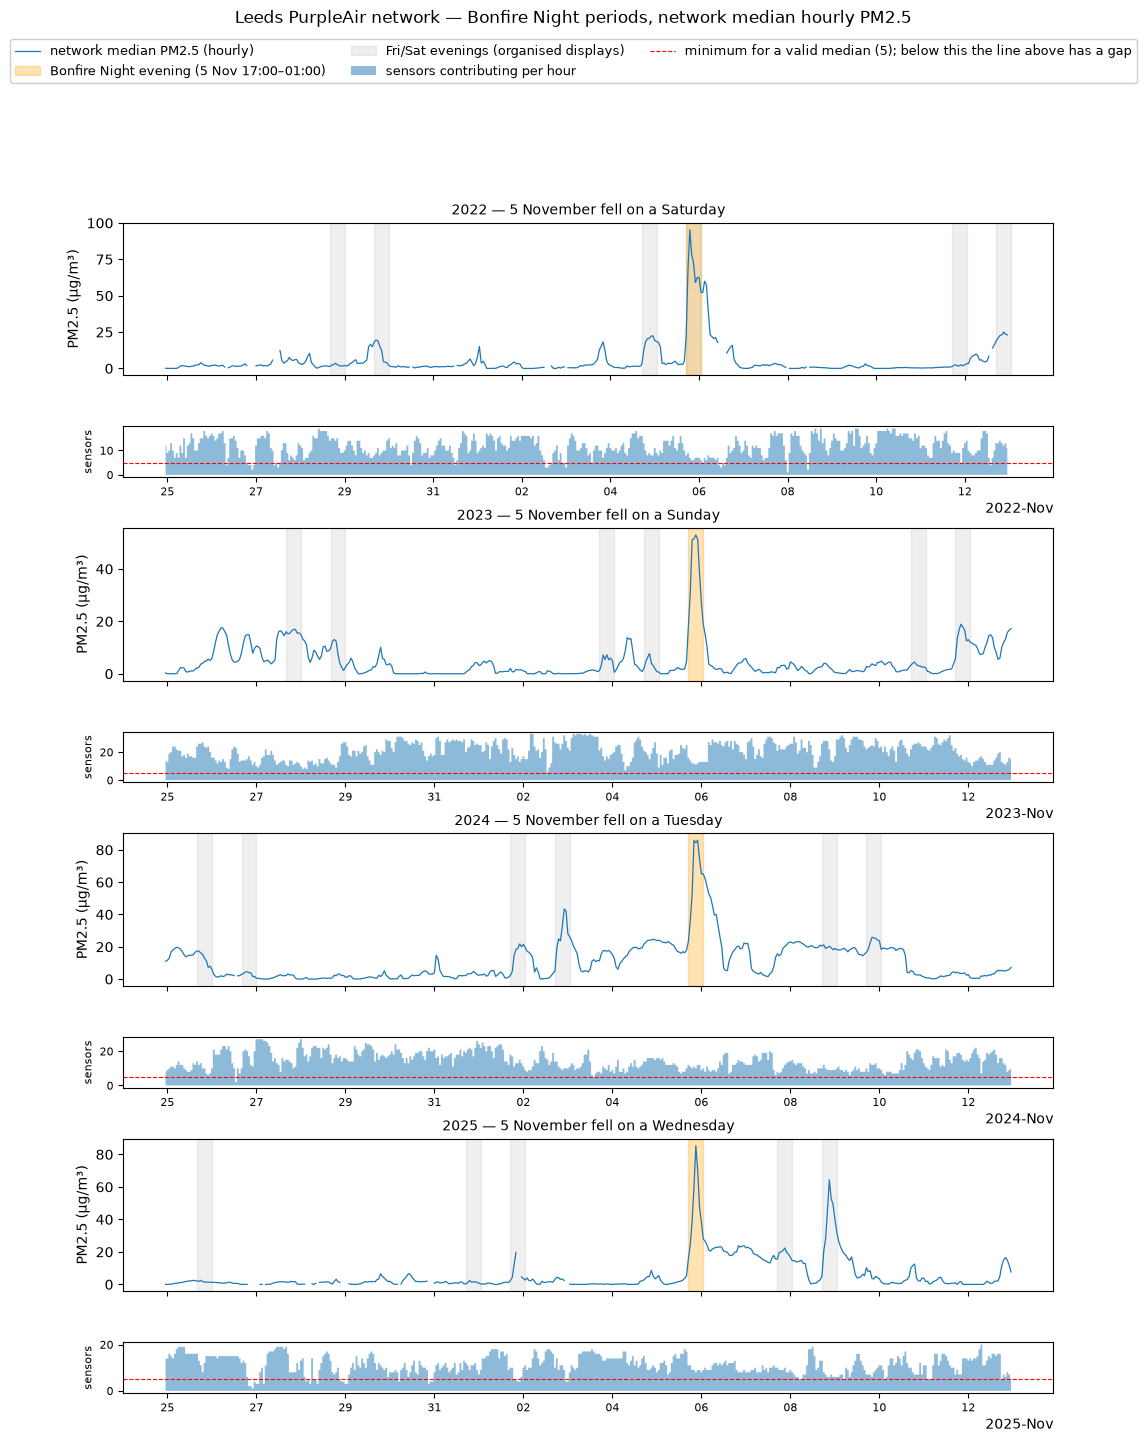

In [ ]:
import matplotlib.dates as mdates

fig = plt.figure(figsize=(12, 3.8 * len(BONFIRE_YEARS)))
gs  = fig.add_gridspec(2 * len(BONFIRE_YEARS), 1,
                       height_ratios=[3, 1] * len(BONFIRE_YEARS),
                       hspace=0.5)

for k, yr in enumerate(BONFIRE_YEARS):
    ax  = fig.add_subplot(gs[2 * k])
    axn = fig.add_subplot(gs[2 * k + 1], sharex=ax)

    t0, t1 = f"{yr}-10-25", f"{yr}-11-12"
    win, nwin = net_local.loc[t0:t1], n_local.loc[t0:t1]

    # --- main panel -----------------------------------------------------
    ax.plot(win.index, win.values, lw=0.9,
            label="network median PM2.5 (hourly)")
    ev = pd.Timestamp(f"{yr}-11-05 17:00", tz=LOCAL_TZ)
    ax.axvspan(ev, ev + pd.Timedelta(hours=8), color="orange", alpha=0.3,
               label="Bonfire Night evening (5 Nov 17:00\u201301:00)")
    first = True
    for d in pd.date_range(t0, t1, tz=LOCAL_TZ):
        if d.dayofweek in (4, 5):
            ax.axvspan(d + pd.Timedelta(hours=17),
                       d + pd.Timedelta(hours=25), color="grey", alpha=0.12,
                       label="Fri/Sat evenings (organised displays)"
                             if first else None)
            first = False
    wd = pd.Timestamp(f"{yr}-11-05").strftime("%A")
    ax.set_title(f"{yr} — 5 November fell on a {wd}", fontsize=10)
    ax.set_ylabel("PM2.5 (\u00b5g/m\u00b3)")
    ax.tick_params(labelbottom=False)          # dates live on the strip below

    # --- sensor strip ----------------------------------------------------
    axn.fill_between(nwin.index, nwin.values, step="mid", alpha=0.5,
                     label="sensors contributing per hour")
    axn.axhline(MIN_SENSORS_PER_HOUR, color="red", ls="--", lw=0.8,
                label=f"minimum for a valid median ({MIN_SENSORS_PER_HOUR}); "
                      f"below this the line above has a gap")
    axn.set_ylabel("sensors", fontsize=8)
    axn.tick_params(labelsize=8)

    # fresh locator/formatter PER AXIS — these objects must not be shared
    loc = mdates.DayLocator(interval=2)
    axn.xaxis.set_major_locator(loc)
    axn.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

    if k == 0:                                  # one legend for the whole figure
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = axn.get_legend_handles_labels()
        fig.legend(h1 + h2, l1 + l2, loc="upper center",
                   bbox_to_anchor=(0.5, 1.005), ncols=3, fontsize=9,
                   framealpha=0.95)

fig.suptitle("Leeds PurpleAir network — Bonfire Night periods, "
             "network median hourly PM2.5", y=1.02, fontsize=12)
fig.savefig(OUT_FIGURES / "bonfire_timeseries_wide.png", dpi=150,
            bbox_inches="tight")
plt.show()

### Diurnal composite, noon 5 Nov -> noon 6 Nov

Re-centred so the whole event arc (rise ~17:00, peak ~21:00, overnight decay) sits unbroken mid-frame. Controls are the same noon->noon clock window on ordinary days (windows starting 2–7 Nov excluded so surrounding-display evenings don't contaminate the baseline).

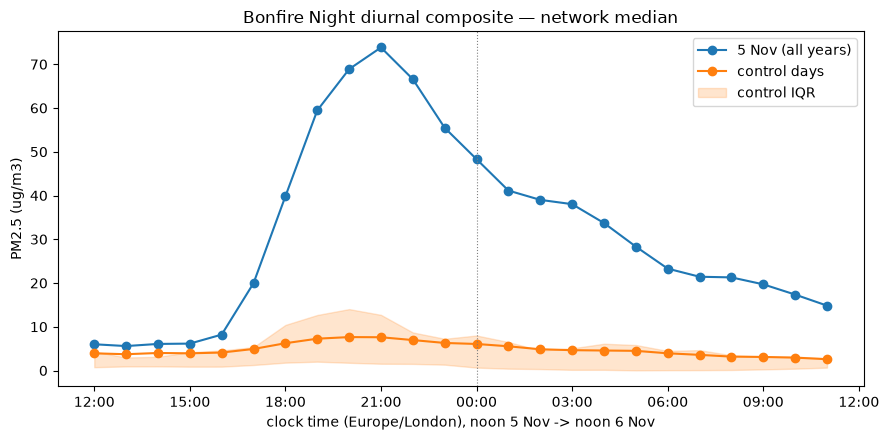

In [ ]:
def noon_window(series, day, tz=LOCAL_TZ):
    """Slice noon on `day` -> noon next day; index = hours since noon."""
    t0 = pd.Timestamp(f"{day} 12:00", tz=tz)
    s  = series.loc[t0: t0 + pd.Timedelta(hours=23, minutes=59)].copy()
    s.index = ((s.index - t0).total_seconds() / 3600).astype(int)
    return s

ev_curves, ctl_curves = [], []
for yr in BONFIRE_YEARS:
    e = noon_window(net_local, f"{yr}-11-05")
    if e.notna().sum():
        ev_curves.append(e)
    for d in pd.date_range(f"{yr}-10-25", f"{yr}-11-14"):
        if d.strftime("%m-%d") not in ["11-02"] + EVENT_EXCLUDE:
            c = noon_window(net_local, d.date())
            if c.notna().sum() >= 12:
                ctl_curves.append(c)

ev_mean  = pd.concat(ev_curves,  axis=1).mean(axis=1)
ctl_all  = pd.concat(ctl_curves, axis=1)
ctl_mean = ctl_all.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ev_mean.index,  ev_mean.values,  marker="o", label="5 Nov (all years)")
ax.plot(ctl_mean.index, ctl_mean.values, marker="o", label="control days")
ax.fill_between(ctl_mean.index,
                ctl_all.quantile(0.25, axis=1),
                ctl_all.quantile(0.75, axis=1), alpha=0.2, color="tab:orange", label="control IQR")
ticks = range(0, 25, 3)
ax.set_xticks(list(ticks))
ax.set_xticklabels([f"{(12 + h) % 24:02d}:00" for h in ticks])
ax.axvline(12, color="grey", ls=":", lw=0.8)   # midnight
ax.set_xlabel(f"clock time ({LOCAL_TZ}), noon 5 Nov -> noon 6 Nov")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Bonfire Night diurnal composite — network median")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIGURES / "bonfire_composite_noon.png", dpi=150)
plt.show()

### Enhancement table 

Event window 18:00 on the 5th -> 02:00 on the 6th (timestamps, so the midnight crossing is handled); controls are the same clock window on 25 Oct – 15 Nov excluding 3–7 Nov.

In [ ]:
rows = []
for yr in BONFIRE_YEARS:
    w0 = pd.Timestamp(f"{yr}-11-05 18:00", tz=LOCAL_TZ)
    ev = net_local.loc[w0: w0 + pd.Timedelta(hours=7, minutes=59)]
    if ev.notna().sum() == 0:
        print(f"  {yr}: no valid network hours in the event window — skipped")
        continue
    season = net_local.loc[f"{yr}-10-25":f"{yr}-11-15"]
    ctl = season[~season.index.strftime("%m-%d").isin(EVENT_EXCLUDE)]
    ctl = ctl[(ctl.index.hour >= 18) | (ctl.index.hour < 2)]
    rows.append({"year": yr,
                 "event_evening_mean":   round(ev.mean(), 2),
                 "control_evening_mean": round(ctl.mean(), 2),
                 "enhancement":          round(ev.mean() - ctl.mean(), 2),
                 "ratio":                round(ev.mean() / ctl.mean(), 2),
                 "valid_event_hours":    int(ev.notna().sum())})

bonfire_stats = pd.DataFrame(rows)
bonfire_stats.to_csv(OUT_TABLES / "bonfire_enhancement.csv", index=False)
print(bonfire_stats.to_string(index=False))

 year  event_evening_mean  control_evening_mean  enhancement  ratio  valid_event_hours
 2022               68.82                  6.34        62.48  10.85                  8
 2023               40.24                  5.35        34.89   7.52                  8
 2024               68.65                  9.07        59.58   7.57                  8
 2025               49.03                  5.70        43.32   8.60                  8


### Map — per-sensor bonfire enhancement (all years pooled)

Each sensor's own 5-Nov-evening mean minus its own control-evening mean. Every dot lighting up = city-wide event (not a sensor artefact); the gradient shows where firework activity is most intense. Sensors with < 8 valid event hours or < 30 control hours are dropped.

20 sensors with enough event coverage; range 28.0 – 91.3 ug/m3


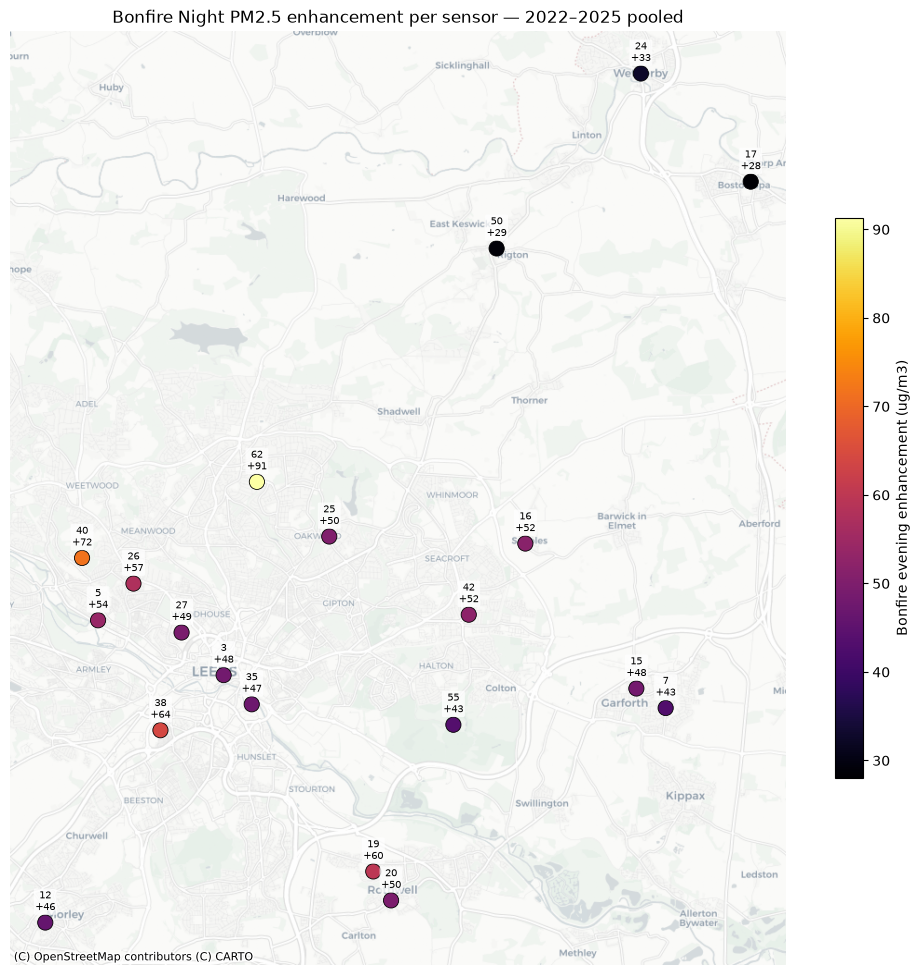

In [ ]:
import contextily as cx

enh = {}
for s in hm.columns:
    x = hm[s].copy(); x.index = x.index.tz_convert(LOCAL_TZ)
    ev_parts, ctl_parts = [], []
    for yr in BONFIRE_YEARS:
        w0 = pd.Timestamp(f"{yr}-11-05 18:00", tz=LOCAL_TZ)
        ev_parts.append(x.loc[w0: w0 + pd.Timedelta(hours=7, minutes=59)])
        c = x.loc[f"{yr}-10-25":f"{yr}-11-15"]
        c = c[~c.index.strftime("%m-%d").isin(EVENT_EXCLUDE)]
        ctl_parts.append(c[(c.index.hour >= 18) | (c.index.hour < 2)])
    ev, ctl = pd.concat(ev_parts), pd.concat(ctl_parts)
    if ev.notna().sum() >= 8 and ctl.notna().sum() >= 30:
        enh[short_code(s)] = ev.mean() - ctl.mean()

enh = pd.Series(enh, name="enhancement")
enh.to_csv(OUT_TABLES / "bonfire_enhancement_per_sensor.csv")
print(f"{len(enh)} sensors with enough event coverage; "
      f"range {enh.min():.1f} – {enh.max():.1f} ug/m3")

sensors = pd.read_csv(OUT_TABLES / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
m = sensors.set_index("code")[["lat", "lon"]].join(enh, how="inner")

R = 6378137.0
m["x"] = np.radians(m["lon"]) * R
m["y"] = np.log(np.tan(np.pi/4 + np.radians(m["lat"])/2)) * R

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(m["x"], m["y"], c=m["enhancement"], cmap="inferno",
                s=120, edgecolor="black", linewidth=0.6, zorder=3)
for code, row in m.iterrows():
    ax.annotate(f"{code[2:].lstrip('0')}\n+{row.enhancement:.0f}",
                (row.x, row.y), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=7, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white",
                          ec="none", alpha=0.75))
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label="Bonfire evening enhancement (ug/m3)")
ax.set_title("Bonfire Night PM2.5 enhancement per sensor — 2022–2025 pooled")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "bonfire_enhancement_map.png", dpi=200,
            bbox_inches="tight")
plt.show()

## 2. England World Cup 2026 matches (unchanged from v1, boundary fixes included)

Per match: −6h to +8h vs same-weekday controls within ±3 weeks; match window kick-off -> +2h, half-open. Exploratory — 4 events, ~10–15 live sensors, low June baselines.

In [ ]:
# England matches — per-sensor paired differences with a placebo window.
# For each sensor individually: (own match-window mean) - (own mean of the
# same clock-window on same-weekday control days). No network-hour rule, so
# evenings with <5 sensors still contribute. The placebo window (-4h to -1h)
# measures how unusual the DAY was before kick-off: the day-adjusted effect
# is match minus placebo.

PLACEBO = (-4, -1)          # hours relative to kick-off
match_days = {pd.Timestamp(ts).date() for _, ts in ENGLAND_MATCHES}

def control_days_for(kick, weeks=3):
    return [(kick + pd.Timedelta(weeks=w)).date()
            for w in range(-weeks, weeks + 1)
            if w != 0 and (kick + pd.Timedelta(weeks=w)).date() not in match_days]

def window_mean(x, start, hours, min_hours=1):
    w = x.loc[start: start + pd.Timedelta(hours=hours) - pd.Timedelta(minutes=1)]
    return w.mean() if w.notna().sum() >= min_hours else np.nan

def per_sensor_diffs(kick, offset_h, length_h):
    """Series of paired differences, one per sensor with enough coverage."""
    out = {}
    for s in hm.columns:
        ev  = window_mean(hm[s], kick + pd.Timedelta(hours=offset_h), length_h)
        ctl = [window_mean(hm[s],
                           pd.Timestamp.combine(d, kick.time()).tz_localize(LOCAL_TZ)
                           + pd.Timedelta(hours=offset_h), length_h)
               for d in control_days_for(kick)]
        ctl = [c for c in ctl if pd.notna(c)]
        if pd.notna(ev) and len(ctl) >= 2:          # sensor needs >=2 control days
            out[s] = ev - np.mean(ctl)
    return pd.Series(out, dtype=float)

# hm must be indexed in local time for this section:
hm_local = hm.copy(); hm_local.index = hm_local.index.tz_convert(LOCAL_TZ)
hm = hm_local

rows, diff_store = [], {}
for label, ts in ENGLAND_MATCHES:
    kick = pd.Timestamp(ts, tz=LOCAL_TZ)
    d_match   = per_sensor_diffs(kick, 0, MATCH_HOURS)
    d_placebo = per_sensor_diffs(kick, PLACEBO[0], PLACEBO[1] - PLACEBO[0])
    diff_store[label] = (d_match, d_placebo)
    rows.append({"match": label,
                 "n_sensors":           len(d_match),
                 "median_diff_match":   round(d_match.median(), 2),
                 "pct_negative":        round(100 * (d_match < 0).mean()),
                 "median_diff_placebo": round(d_placebo.median(), 2),
                 "day_adjusted_effect": round(d_match.median()
                                              - d_placebo.median(), 2)})

match_stats = pd.DataFrame(rows)
match_stats.to_csv(OUT_TABLES / "england_match_paired.csv", index=False)
print(match_stats.to_string(index=False))

          match  n_sensors  median_diff_match  pct_negative  median_diff_placebo  day_adjusted_effect
Croatia (group)          9              -0.00            56                -0.91                 0.91
  Ghana (group)          3              10.06             0                11.27                -1.22
 Panama (group)          4               1.59             0                 1.47                 0.12
 DR Congo (R32)          8              -2.13           100                -3.35                 1.22


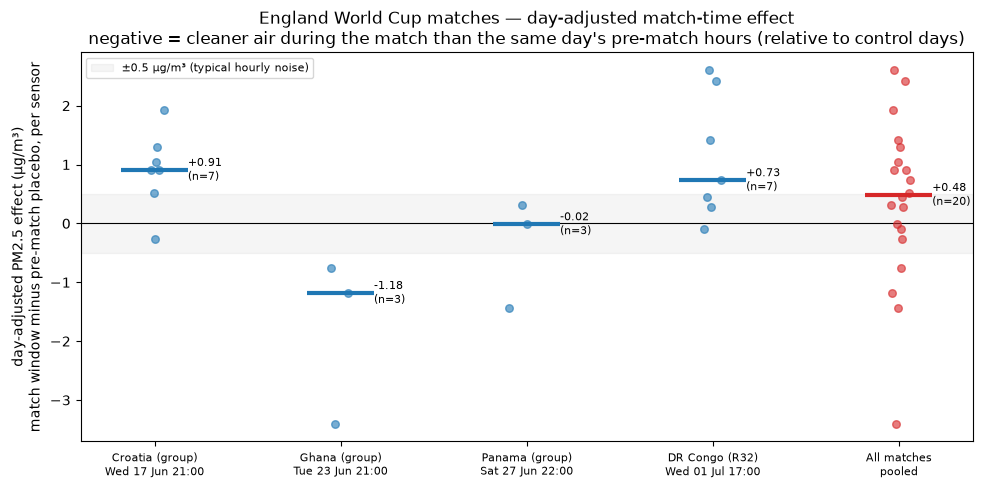

pooled median day-adjusted effect: +0.48 ug/m3 across 20 sensor-matches (35% negative)


In [ ]:
# Day-adjusted per-sensor effects: for each sensor with BOTH windows,
# (match diff) - (placebo diff). This cancels whatever made the whole day
# unusual (weather, regional episodes) and isolates the match-time signal.

adj_store, pooled = {}, []
for label, ts in ENGLAND_MATCHES:
    d_match, d_placebo = diff_store[label]
    adj = (d_match - d_placebo).dropna()
    adj_store[label] = adj
    pooled.extend(adj.values)
pooled = pd.Series(pooled, name="adjusted_effect")

groups = list(adj_store.items()) + [("All matches\npooled", pooled)]

fig, ax = plt.subplots(figsize=(10, 5))
jit = np.random.default_rng(0)
for i, (label, d) in enumerate(groups):
    col = "tab:blue" if i < len(ENGLAND_MATCHES) else "tab:red"
    x = i + jit.normal(0, 0.04, len(d))
    ax.scatter(x, d.values, s=30, alpha=0.6, color=col, zorder=3)
    if len(d):
        ax.hlines(d.median(), i - 0.18, i + 0.18, color=col, lw=3, zorder=4)
        ax.annotate(f"{d.median():+.2f}\n(n={len(d)})", (i, d.median()),
                    textcoords="offset points", xytext=(24, 0),
                    fontsize=8, va="center")
ax.axhline(0, color="black", lw=0.8)
ax.axhspan(-0.5, 0.5, color="grey", alpha=0.08,
           label="\u00b10.5 \u00b5g/m\u00b3 (typical hourly noise)")
labels = [f"{l}\n{pd.Timestamp(t):%a %d %b %H:%M}" for l, t in ENGLAND_MATCHES]
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(labels + ["All matches\npooled"], fontsize=8)
ax.set_ylabel("day-adjusted PM2.5 effect (\u00b5g/m\u00b3)\n"
              "match window minus pre-match placebo, per sensor")
ax.set_title("England World Cup matches — day-adjusted match-time effect\n"
             "negative = cleaner air during the match than the same day's pre-match hours "
             "(relative to control days)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_FIGURES / "england_adjusted_effects.png", dpi=150)
plt.show()

print(f"pooled median day-adjusted effect: {pooled.median():+.2f} ug/m3 "
      f"across {len(pooled)} sensor-matches "
      f"({100*(pooled<0).mean():.0f}% negative)")